In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv(r"C:\Users\YOUEXCEL\Downloads\archive (1)\Bank_Personal_Loan_Modelling(1).csv")


df = df.drop(["ID","ZIP Code","Securities Account"], axis=1)
# adding matarial status
df["Marital status"]= np.random.randint(1,3,size=len(df))





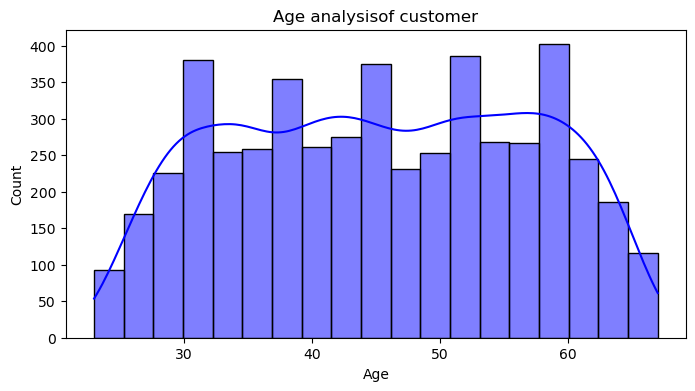

In [2]:
#visualizing the age distribution of customer using a histogram
plt.figure(figsize=(8,4))
sns.histplot(df['Age'],kde=True,color='blue')
plt.title('Age analysisof customer')
plt.show()

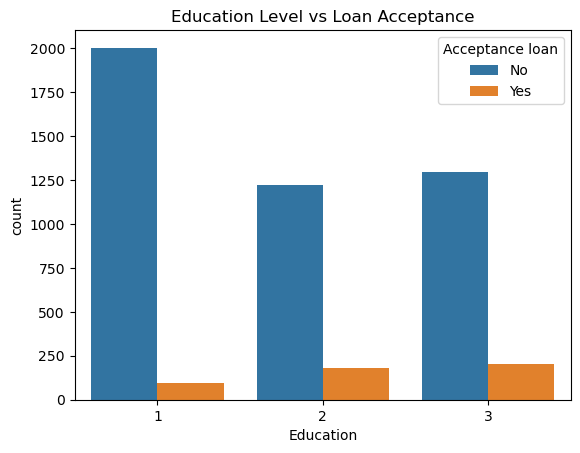

In [11]:
 #Education as a proxy for job(Requirement job)
#1;undergraduate,2; graduate,3 ;professional
sns.countplot(x='Education',hue='Personal Loan', data=df)
plt.title('Education Level vs Loan Acceptance')
plt.legend(title='Acceptance loan',labels=['No','Yes'])
plt.show()

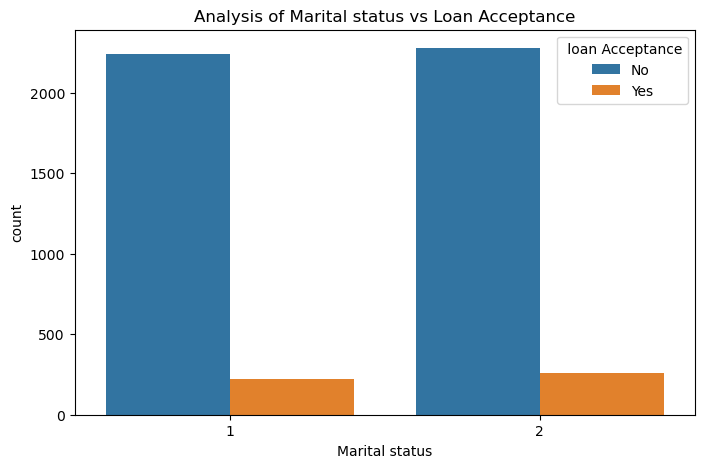

In [13]:
#marital status
plt.figure(figsize=(8,5))
sns.countplot(x='Marital status',hue='Personal Loan', data=df)
plt.title('Analysis of Marital status vs Loan Acceptance')
plt.legend(title=' loan Acceptance',labels=['No','Yes'])
plt.show()

In [20]:
# Splitting data into Training (80%) and Testing (20%) sets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df[['Age', 'Education', 'Marital status']]
y = df['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#(Logistic Regression machine)
model = LogisticRegression()

#(Training)
model.fit(X_train, y_train)

#(Prediction)
predictions = model.predict(X_test)

#Result
accuracy = accuracy_score(y_test, predictions)
print(f"Machine Learning Accuracy: {accuracy * 100:.2f}%")


Machine Learning Accuracy: 89.50%


In [21]:
importance = model.coef_[0]
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
print(feature_importance_df.sort_values(by='Importance', ascending=False))

          Feature  Importance
1       Education    0.525666
2  Marital status    0.117013
0             Age   -0.001899
